# Hybrid Quantum-Classical Reinforcement Learning (3/3)

___
___

## Introduction
___


In this article, the authors apply hybrid quantum-classical Reinforcement Learning (RL) models to two simulated environments. They compare classical, qubit-based and photonic-based agents, all using Proximal Policy Optimization (PPO). They also use an AutoEncoder (AE) to compress the dimensionality of the observations and train that AE jointly with the PPO agents.

The notebook series aims to compare the resources cost of the different systems to reach the same performance. It is divided in three parts:

- [Part I: Classical vs Qubit agents on the Cart Pole environment](QRL_experiment_1.ipynb)
- [Part II: Classical vs Qubit agents on the Lunar Lander and Maze environments](QRL_experiment_2.ipynb)
- **Part III: Photonic agents on the three environments**

This third notebook will present:
1. Photonic-based PPO
2. Results on Cart Pole
3. Results on Lunar Lander
4. Results on Maze
5. Conclusion

In [6]:
# Uncomment the following line to install dependencies if needed
# !pip install ipynb setuptools==77.0.3 torch torchvision gymnasium swig "gymnasium[box2d]" matplotlib  autoray==0.7.2 scipy==1.13.0 pennylane==0.29.1 StrawberryFields==0.23.0 PennyLane-SF==0.29.1

In [ ]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import gymnasium as gym
import pennylane as qp
from MazeEnvironment import Maze

from ipynb.fs.defs.QRL_experiment_1 import AutoEncoder, PPO, CriticNN, MemoryTracker, count_parameters, save_results, plot_results
from ipynb.fs.defs.QRL_experiment_2 import ConvolutionalAE, MazePPO, CriticCNN

# For reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)

# Code works on CPU and GPU
device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "cpu"
)

# The results are saved in qrl_results/qrl_results.json
results_folder = "qrl_results"
os.makedirs(results_folder, exist_ok=True)
results_filepath = os.path.join(results_folder, "qrl_results.json")

## 1 - Photonic-based PPO
___

The photonic version of PPO uses a continuous-variable (CV) quantum circuit, where information is encoded in the quantum states of optical modes rather than qubits. The photonic quantum circuit used in the article is composed of squeezing, displacement, rotation, and Kerr gates.

<div align="center">
<img src="images/qrl_demo_cvqnn.png" width="500"/>
</div>

The Kerr gate introduces the non-linearity required by the circuit. To run this implementation, we use the Strawberry Fields backend with a deprecated version of PennyLane that still supports the Kerr gate.

In [ ]:
class ActorPhotonicNN(nn.Module):
    def __init__(self, input_shape, intermediate_dim, output_dim, device):
        super().__init__()
        self.device = device
        input_dim = input_shape
        n_modes = input_shape//2
        n_layers = intermediate_dim

        shapes = qp.CVNeuralNetLayers.shape(n_layers=n_layers, n_wires=n_modes)
        weight_shapes = {
            name: shape for name, shape in zip(
                ["theta_1", "phi_1", "varphi_1", "r", "phi_r",
                 "theta_2", "phi_2", "varphi_2", "a", "phi_a", "k"],
                shapes,
            )
        }
        
        dev = qp.device("strawberryfields.fock", wires=n_modes, cutoff_dim=10)

        @qp.qnode(dev, interface="torch")
        def qnode(inputs, **weights):
            qp.Squeezing(1/2, np.pi/2, wires=range(n_modes))
            qp.templates.embeddings.DisplacementEmbedding(inputs, wires=range(n_modes))
            qp.CVNeuralNetLayers(*weights.values(), wires=range(n_modes))
            return [qp.expval(qp.X(i)) for i in range(n_modes)]

        self.layer1 = nn.Linear(input_dim, n_modes).to(self.device)
        self.qlayer1 = qp.qnn.TorchLayer(qnode, weight_shapes)
        self.layer2 = nn.Linear(n_modes, output_dim).to(self.device)

    def forward(self, x):
        x = self.layer1(x)
        x = self.qlayer1(x.cpu()).to(self.device)
        x = self.layer2(x)
        return x

## 2 - Results on Cart Pole

In [ ]:
# Create the environment
cartpole_env = gym.make("CartPole-v1", render_mode="rgb_array")
cartpole_env.reset(seed=seed)
cartpole_env.action_space.seed(seed)
cartpole_env.observation_space.seed(seed)
env_name = "Cart Pole"

# Create the config
cp_config = {
    "ae_hidden_dim": 32, "ae_output_dim": 2,
    "critic_intermediate_dim": 64, "minibatch_size": 128, "lr": 1e-3,
    "K": 10, "episode_update_frequency": 1, "mean_reward_lookback": 20, "mean_reward_stop": 480,
    "gamma": 0.98, "lambda": 0.8, "epsilon": 0.2, "entropy_coeff": 0.01, "print_steps_frequency": 10000
    }
cp_config["actor_intermediate_dim"] = 1

# Launch training
with MemoryTracker() as cp_photonic_stats:
    cp_photonic_ppo = PPO(AutoEncoderClass=AutoEncoder, ActorClass=ActorPhotonicNN, CriticClass=CriticNN, env=cartpole_env, config=cp_config, device=device)
    cp_photonic_parameters = count_parameters(cp_photonic_ppo.actor)
    cp_photonic_mean_rewards, cp_photonic_training_time = cp_photonic_ppo.run()
photonic_results = { 
    "training_time": cp_photonic_training_time, 
    "mean_rewards": cp_photonic_mean_rewards, 
    "parameters": cp_photonic_parameters, 
    "memory": cp_photonic_stats.peak_rss_mb
}
torch.save(cp_photonic_ppo.autoencoder.state_dict(), os.path.join(results_folder, "cp_photonic_ae.pt"))
torch.save(cp_photonic_ppo.actor.state_dict(), os.path.join(results_folder, "cp_photonic_actor.pt"))
torch.save(cp_photonic_ppo.critic.state_dict(), os.path.join(results_folder, "cp_photonic_critic.pt"))
qrl_results = save_results(results_filepath, env_name, "photonic", photonic_results)


Step 10: mean reward = 0.00 (0:00:00.056020)

Step 20: mean reward = 18.00 (0:00:00.045356)

Step 30: mean reward = 18.00 (0:00:00.052027)

Step 40: mean reward = 18.00 (0:00:00.043514)

Step 50: mean reward = 22.00 (0:00:00.040021)

Step 60: mean reward = 18.33 (0:00:00.047653)

Step 70: mean reward = 18.33 (0:00:00.048010)

Step 80: mean reward = 19.50 (0:00:00.044197)

Step 90: mean reward = 19.50 (0:00:00.045518)

Step 100: mean reward = 19.50 (0:00:00.040780)

Step 110: mean reward = 21.80 (0:00:00.041174)

Step 120: mean reward = 21.80 (0:00:00.042366)

Step 130: mean reward = 20.17 (0:00:00.043792)

Step 140: mean reward = 19.71 (0:00:00.041524)

Step 150: mean reward = 19.71 (0:00:00.045031)

Step 160: mean reward = 19.50 (0:00:00.048665)

Step 170: mean reward = 18.56 (0:00:00.044721)

Step 180: mean reward = 18.56 (0:00:00.039366)

Step 190: mean reward = 18.56 (0:00:00.037567)

Step 200: mean reward = 19.10 (0:00:00.038519)

Step 210: mean reward = 18.27 (0:00:00.041432)

S

KeyboardInterrupt: 

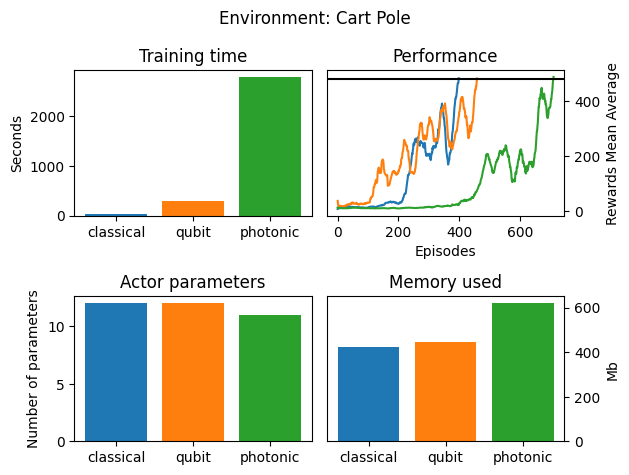

In [12]:
plot_results(env_name, qrl_results[env_name], cp_config["mean_reward_stop"], methods=["classical", "qubit", "photonic"])

## 3 - Results on Lunar Lander

In [ ]:
# Create the environment
lunarlander_env = gym.make("LunarLander-v3", render_mode="rgb_array")
lunarlander_env.reset(seed=seed)
lunarlander_env.action_space.seed(seed)
lunarlander_env.observation_space.seed(seed)
env_name = "Lunar Lander"

# Create the config
ll_config = {
    "ae_hidden_dim": 64, "ae_output_dim": 3,
    "critic_intermediate_dim": 128,
    "minibatch_size": 64, "lr": 3e-4,
    "K": 4, "episode_update_frequency": 1, "mean_reward_lookback": 50, "mean_reward_stop": 220,
    "gamma": 0.99, "lambda": 0.98, "epsilon": 0.2, "entropy_coeff": 0.01, "print_steps_frequency": 100000
    }
ll_config["actor_intermediate_dim"] = 2

# Launch training
with MemoryTracker() as ll_photonic_stats:
    ll_photonic_ppo = PPO(AutoEncoderClass=AutoEncoder, ActorClass=ActorPhotonicNN, CriticClass=CriticNN, env=lunarlander_env, config=ll_config, device=device)
    ll_photonic_parameters = count_parameters(ll_photonic_ppo.actor)
    ll_photonic_mean_rewards, ll_photonic_training_time = ll_photonic_ppo.run()
photonic_results = { 
    "training_time": ll_photonic_training_time, 
    "mean_rewards": ll_photonic_mean_rewards, 
    "parameters": ll_photonic_parameters, 
    "memory": ll_photonic_stats.peak_rss_mb
}
torch.save(ll_photonic_ppo.autoencoder.state_dict(), os.path.join(results_folder, "ll_photonic_ae.pt"))
torch.save(ll_photonic_ppo.actor.state_dict(), os.path.join(results_folder, "ll_photonic_actor.pt"))
torch.save(ll_photonic_ppo.critic.state_dict(), os.path.join(results_folder, "ll_photonic_critic.pt"))
qrl_results = save_results(results_filepath, env_name, "photonic", photonic_results)


Step 1000: mean reward = -244.86 (0:01:25.894701)

Step 2000: mean reward = -231.68 (0:01:25.161674)

Step 3000: mean reward = -247.56 (0:01:25.148131)

Step 4000: mean reward = -253.71 (0:01:25.073545)

Step 5000: mean reward = -239.74 (0:01:24.933254)

Step 6000: mean reward = -264.66 (0:01:24.923933)

Step 7000: mean reward = -258.72 (0:01:25.167961)

Step 8000: mean reward = -262.52 (0:01:24.942287)

Step 9000: mean reward = -254.54 (0:01:25.073320)

Step 10000: mean reward = -242.91 (0:01:25.284584)

Step 11000: mean reward = -212.98 (0:01:25.162248)

Step 12000: mean reward = -216.97 (0:01:25.118743)

Step 13000: mean reward = -197.33 (0:01:27.889316)

Step 14000: mean reward = -206.57 (0:01:26.483033)

Step 15000: mean reward = -213.91 (0:01:23.403273)

Step 16000: mean reward = -229.16 (0:01:23.651579)

Step 17000: mean reward = -241.26 (0:01:23.590038)

Step 18000: mean reward = -250.10 (0:01:23.647179)

Step 19000: mean reward = -236.90 (0:01:23.212699)

Step 20000: mean rew

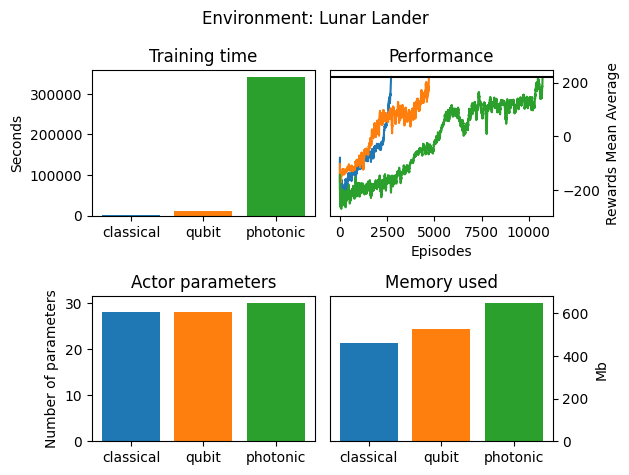

In [16]:
plot_results(env_name, qrl_results[env_name], ll_config["mean_reward_stop"], methods=["classical", "qubit", "photonic"])

## 4 - Results on Maze

In [ ]:
# Create the environment
maze_env = Maze()
maze_env.reset(seed=seed)
maze_env.action_space.seed(seed)
maze_env.observation_space.seed(seed)
env_name = "Maze"

# Create the config
m_config = {
    "image_size": 64,
    "ae_hidden_dim": 128, "ae_output_dim": 12, 
    "ae_pretrain_epochs": 5000, "ae_pretrain_n_examples": 100000, "ae_pretrain_batchsize": 64,
    "critic_intermediate_dim": 128,
    "minibatch_size": 128, "lr": 1e-4,
    "K": 8, "episode_update_frequency": 20, "mean_reward_lookback": 30, "mean_reward_stop": 0.9,
    "curriculum_levels": [
        (0, 0, 0, 1), # Level 1
        (0, 0, 0, 3), # Level 2
        (0, 0, 0, 5), # Level 3
        (1, 1, 4, 3), # Level 4
        (1, 1, 4, 5), # Level 5
        (2, 2, 8, 3), # Level 6
        (2, 2, 8, 5), # Level 7
        (3, 3, 8, 3), # Level 8
        (3, 3, 8, 5), # Level 9
        None],        # Level 10
    "gamma": 0.99, "lambda": 0.95, "epsilon": 0.2, "entropy_coeff": 0.01, "print_steps_frequency": 1000000
    }
custom_obs_shape = (m_config["image_size"], m_config["image_size"], 3)
m_config["actor_intermediate_dim"] = 1

# Launch training
with MemoryTracker() as m_photonic_stats:
    m_photonic_ppo = MazePPO(AutoEncoderClass=ConvolutionalAE, ActorClass=ActorPhotonicNN, CriticClass=CriticCNN, env=maze_env, config=m_config, device=device, custom_obs_shape=custom_obs_shape, results_folder=results_folder)
    m_photonic_parameters = count_parameters(m_photonic_ppo.actor)
    m_photonic_mean_rewards, cr_photonic_training_time = m_photonic_ppo.run()
photonic_results = { 
    "training_time": cr_photonic_training_time, 
    "mean_rewards": m_photonic_mean_rewards, 
    "parameters": m_photonic_parameters, 
    "memory": m_photonic_stats.peak_rss_mb
}
torch.save(m_photonic_ppo.autoencoder.state_dict(), os.path.join(results_folder, "m_photonic_ae.pt"))
torch.save(m_photonic_ppo.actor.state_dict(), os.path.join(results_folder, "m_photonic_actor.pt"))
torch.save(m_photonic_ppo.critic.state_dict(), os.path.join(results_folder, "m_photonic_critic.pt"))
qrl_results = save_results(results_filepath, env_name, "photonic", photonic_results)

  peak process RSS :   1708.3 MB  (Δ +1248.0 MB)
  peak MPS allocated (polled):      0.0 MB


KeyboardInterrupt: 

In [17]:
plot_results(env_name, qrl_results[env_name], m_config["mean_reward_stop"], methods=["classical", "qubit", "photonic"])

NameError: name 'm_config' is not defined

## 5 - Conclusion
___

It takes a lot less photonic qumodes and layers to reach the same amount of parameters. Training time is the biggest limitation here though, with the simulation taking much longer than the classical and qubit-based methods.

In the article, the authors used an alternative to the no-longer maintained Strawberry-Fields photonic library: [Piquasso](https://github.com/Budapest-Quantum-Computing-Group/piquasso). You can find more information about it in this article: ["Piquasso: A Photonic Quantum Computer Simulation Software Platform"](https://arxiv.org/pdf/2403.04006)